# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

In [9]:
!pip install shap

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)



# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

ModuleNotFoundError: No module named 'sklearn'

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [29]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from pycaret.classification import setup, compare_models, pull

df = pd.read_csv("Bank Customer Churn Prediction.csv") #데이터 불러오기

print("===== 데이터 크기 =====")    #데이터 로드 후 파악하기 (데이터 크기, 상위 5행, 데이터 정보, 결측치 개수)
print(df.shape)

print("\n===== 상위 5행 =====")
print(df.head())

print("\n===== 데이터 정보 =====")
df.info()

print("\n===== 결측치 개수 =====")
print(df.isnull().sum())

===== 데이터 크기 =====
(10000, 12)

===== 상위 5행 =====
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100

In [30]:
df["country"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [31]:
#전처리
df = df.drop(columns=["customer_id"], errors="ignore") 
#고객 고유 식별 번호라 의미없는 데이터라 판단하고 드랍함 
#전처리 하기 위해 필요없는 칼럼을 앞에 확인함

# 범주형 인코딩
le_country = LabelEncoder() #문자형범주데이터 말고, 숫자로 변경하기 위해 인코딩 (알파벳 순서대로  ['France'=0, 'Spain'=2, 'Germany'=1]로 변경됨
le_gender = LabelEncoder()    #알파벳 순서대로 (Female->0 , male->1로 변경됨) 

df["country"] = le_country.fit_transform(df["country"])  #앞에 인코딩한 걸로 변환후 적용 
df["gender"] = le_gender.fit_transform(df["gender"])

#통계값 확인
print("\n===== churn 분포 =====")
print(df["churn"].value_counts()) #이탈 유무(유지=0, 이탈=1이 얼마나 있는 지 확인하기 위함)
print(df["churn"].value_counts(normalize=True)) #이탈 유무를 비율로 확인

print("\n===== 수치형 변수 기술통계량 =====")
print(df.describe()) #요약 통계로 확인

print("\n===== country별 churn 평균 =====")
print(df.groupby("country")["churn"].mean()) #국가별로 이탈 평균 값을 봄

print("\n===== gender별 churn 평균 =====")
print(df.groupby("gender")["churn"].mean()) #성별별로 이탈 평균 값을 봄 


print("\n===== 상관계수 =====")
print(df.corr(numeric_only=True)) #이탈유무와 다른 변수의 상관계수에 대해 볼 수 있음 
# 상관계수를 확인했을 때 제일 높은 비율이 0.2..으로 확인되어서 상관계수가 높은 변수를 찾기 힘들다고 판단함



===== churn 분포 =====
churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

===== 수치형 변수 기술통계량 =====
       credit_score       country        gender           age        tenure  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     650.528800      0.746300      0.545700     38.921800      5.012800   
std       96.653299      0.827529      0.497932     10.487806      2.892174   
min      350.000000      0.000000      0.000000     18.000000      0.000000   
25%      584.000000      0.000000      0.000000     32.000000      3.000000   
50%      652.000000      0.000000      1.000000     37.000000      5.000000   
75%      718.000000      1.000000      1.000000     44.000000      7.000000   
max      850.000000      2.000000      1.000000     92.000000     10.000000   

             balance  products_number  credit_card  active_member  \
count   10000.000000     10000.000000  10000.00000   100

이탈하지 않은 고객이 약 80%, 이탈 고객이 약 20%로 클래스 불균형 데이터인 것을 확인할 수 있음 \
germany 고객의 이탈 비율이 다른 국가 보다 0.324로 높은 것을 확인할 수 있음 \
국가별로 churn 데이터에 영향을 미친다는 것을 알 수 있음 \
여성고객(0)의 이탈률이 0.251로 남성(0.165)보다 높게 나타남 \
성별도 변수로 영향을 미칠 수 있다는 것을 보여줌 \
age와 churn의 상관계수가 0.285로 상대적으로 높은 양의 상관계수를 보여주지만 
상관계수가 낮다고 판단됨\
-> 따라서 선형 모델로는 한계가 있다고 판단되고 비선형 모델도 써야할 것 같음



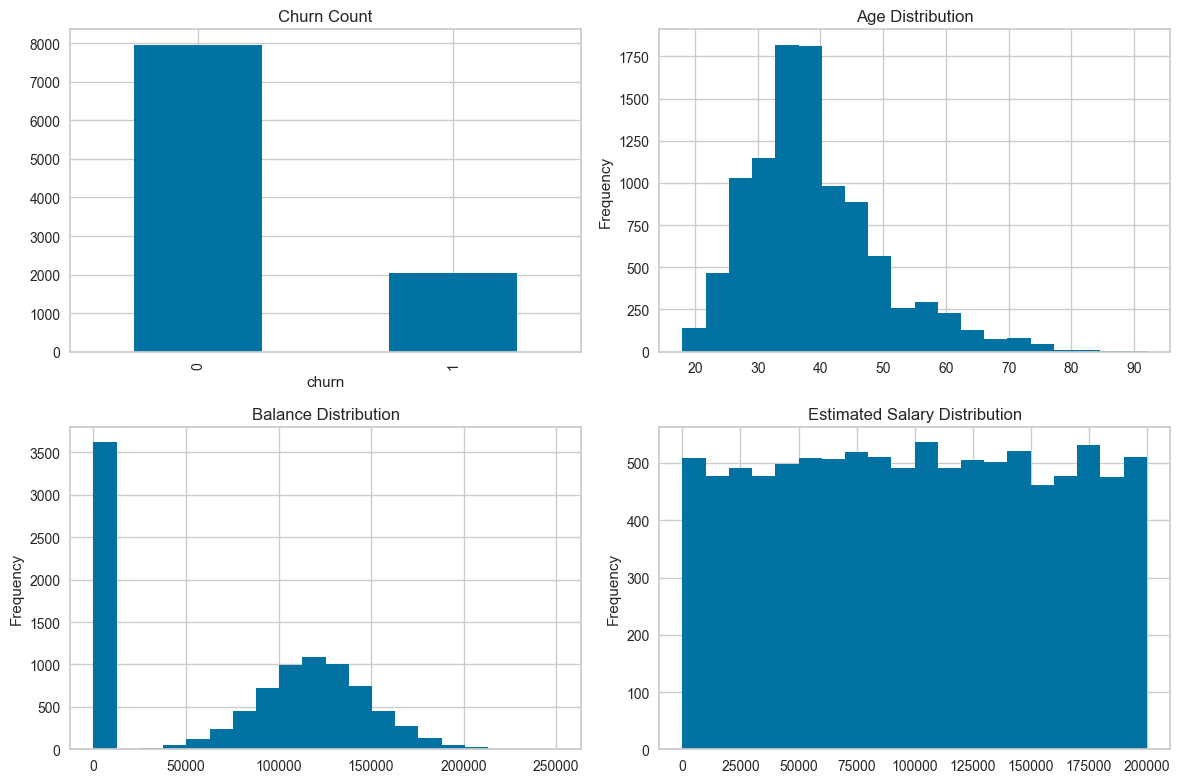

In [32]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) #그래프 크기 설정 

df["churn"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Churn Count")  
df["age"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Age Distribution")
df["balance"].plot(kind="hist", bins=20, ax=axes[1, 0], title="Balance Distribution")
df["estimated_salary"].plot(kind="hist", bins=20, ax=axes[1, 1], title="Estimated Salary Distribution")

plt.tight_layout()
plt.show()



In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

skyblue = "#87CEEB"  # 밝은 하늘색

df["churn"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Churn Count", color=skyblue)
df["age"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Age Distribution", color=skyblue)
df["balance"].plot(kind="hist", bins=20, ax=axes[1, 0], title="Balance Distribution", color=skyblue)
df["estimated_salary"].plot(kind="hist", bins=20, ax=axes[1, 1], title="Estimated Salary Distribution", color=skyblue)

plt.tight_layout()
plt.show()

왼쪽 위 그래프를 봤을 때, 0이 훨씬 많고, 1이 상대적으로 적은 것을 볼 수 있음\
데이터가 불균형 구조라고 판단

오른쪽 위 그래프는 대부분 고객이 30~40대에 집중되어 있고,\
고령층이 소수 존재함을 알 수 있음, 데이터가 특정 연령대에 몰려있음

왼쪽아래 그래프는 잔액이 0인 고객이 매우 많다는 것을 알 수 있음 

오른쪽 아래 그래프는 거의 균등하며, churn 설명력이 약할 가능성이 보임

In [34]:
train_df, valid_df = train_test_split(
    df,                                         #(train, valid)를 (80,20)으로 데이터 분할
    test_size=0.2,
    random_state=42,
    stratify=df["churn"]                        #이탈고객비율이 비슷하게 유지되도록 분할함
)

print("\n===== train / valid 데이터 크기 =====")
print("train_df shape:", train_df.shape)
print("valid_df shape:", valid_df.shape)

clf = setup(
    data=train_df,
    target="churn",
    session_id=42,
    verbose=False
)


best_model = compare_models(sort="F1") #모든 모델 F1 배열

leaderboard = pull()

print("\n===== F1 기준 전체 모델 비교 결과 =====")
print(leaderboard[["Model", "F1", "Accuracy", "AUC", "Recall", "Prec."]])

print("\n===== Best Model (F1 기준 1위) =====")
print(best_model)


===== train / valid 데이터 크기 =====
train_df shape: (8000, 11)
valid_df shape: (2000, 11)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0560
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1260
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1440
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,1.0160
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1550
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0330
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.1090
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0130
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0130
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0100



===== F1 기준 전체 모델 비교 결과 =====
                                    Model      F1  Accuracy     AUC  Recall  \
ada                  Ada Boost Classifier  0.5748    0.8555  0.8496  0.4804   
lightgbm  Light Gradient Boosting Machine  0.5726    0.8559  0.8499  0.4768   
gbc          Gradient Boosting Classifier  0.5708    0.8614  0.8638  0.4549   
catboost              CatBoost Classifier  0.5708    0.8584  0.8641  0.4637   
rf               Random Forest Classifier  0.5593    0.8582  0.8443  0.4436   
xgboost         Extreme Gradient Boosting  0.5555    0.8441  0.8396  0.4786   
et                 Extra Trees Classifier  0.5418    0.8532  0.8424  0.4269   
dt               Decision Tree Classifier  0.4849    0.7862  0.6777  0.4943   
qda       Quadratic Discriminant Analysis  0.4600    0.8457  0.8155  0.3243   
lda          Linear Discriminant Analysis  0.3086    0.8079  0.7611  0.2112   
lr                    Logistic Regression  0.3043    0.8112  0.7433  0.2033   
ridge                

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna

selected_model_ids = ["rf", "lr", "knn", "svm"] #사용할 모델 선정


#데이터 분할
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["churn"]
)

print("train_df shape:", train_df.shape)
print("valid_df shape:", valid_df.shape)

#X,y선정
X_train_df = train_df.drop("churn", axis=1)        #y값인 ['churn']을 제외하고 x 취급
y_train = train_df["churn"]                        #y값인 ['churn']을 y로 취급

X_valid_df = valid_df.drop("churn", axis=1)
y_valid = valid_df["churn"]


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)  #스케일링(크기 차이가 존재할 수 있어 실행)
X_valid = scaler.transform(X_valid_df)      #

def objective_rf(trial):       #f1-score를 최대화 하는 방향으로 하이퍼파라미터를 찾음
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),                   #optuna
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 42
    }

    model = RandomForestClassifier(**params)  #위에서 나온 조합으로 rf 모델 생성
    model.fit(X_train, y_train) 
    pred = model.predict(X_valid)   #예측값

    return f1_score(y_valid, pred)  #f1 score 


def objective_lr(trial):         # 규제강도와 최적화 알고리즘을 탐색
    params = {                   #trial 조합을 만들어주는 변수
        "C": trial.suggest_float("C", 0.001, 10, log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "max_iter": 1000,
        "random_state": 42
    }

    model = LogisticRegression(**params)  
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    return f1_score(y_valid, pred)


def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 21),  
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)
    }

    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    return f1_score(y_valid, pred)


def objective_svm(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 10, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        "probability": True,
        "random_state": 42
    }

    model = SVC(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    return f1_score(y_valid, pred)


objective_dict = {
    "rf": objective_rf,
    "lr": objective_lr,
    "knn": objective_knn,
    "svm": objective_svm
}

studies = {}             #모델의 탐색 결과와 최적 파라미터 저장할 딕셔너리 
best_params = {}

for model_id in selected_model_ids:
    print(f"\n===== Optuna tuning: {model_id} =====")

    study = optuna.create_study(direction="maximize") #f1 score를 최대화 하는 방향으로 만듦
    study.optimize(objective_dict[model_id], n_trials=20) #시도를 20번해서 좋은 파라미터를 찾음

    studies[model_id] = study
    best_params[model_id] = study.best_params

    print(f"{model_id} best F1:", study.best_value) #각 모델의 f1 score가 가장 높은 것 출력
    print(f"{model_id} best params:", study.best_params)  #각 모델의 최적 파라미터를 출력


trained_models = {} #최종 학습모델을 넣을 빈 딕셔너리 

rf_params = best_params["rf"].copy()
rf = RandomForestClassifier(**rf_params, random_state=42)  # Random Forest
rf.fit(X_train, y_train)
trained_models["RF"] = rf


lr_params = best_params["lr"].copy()
lr_params.pop("max_iter", None)
lr_params.pop("random_state", None)

lr = LogisticRegression(**lr_params, max_iter=1000, random_state=42)  # Logistic Regression
lr.fit(X_train, y_train)
trained_models["LR"] = lr

knn_params = best_params["knn"].copy()
knn = KNeighborsClassifier(**knn_params)     # KNN
knn.fit(X_train, y_train)
trained_models["KNN"] = knn

svm_params = best_params["svm"].copy()
svm_params.pop("probability", None)    #svm 
svm_params.pop("random_state", None)

svm = SVC(**svm_params, probability=True, random_state=42)
svm.fit(X_train, y_train)
trained_models["SVM"] = svm

print("\n===== 각 모델별 F1-score =====")

for name, model in trained_models.items():   #각 모델별 f1-score를 출력 
    pred = model.predict(X_valid)      #예측값
    score = f1_score(y_valid, pred)    #예측한 모델로 f1-score를 출력
    print(name, "F1-score:", score)

[I 2026-04-09 17:18:32,010] A new study created in memory with name: no-name-884bd218-30a8-47b6-8f34-bb98821c48b7


train_df shape: (8000, 11)
valid_df shape: (2000, 11)

===== Optuna tuning: rf =====


[I 2026-04-09 17:18:32,886] Trial 0 finished with value: 0.5391014975041597 and parameters: {'n_estimators': 188, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.5391014975041597.
[I 2026-04-09 17:18:33,636] Trial 1 finished with value: 0.5727848101265823 and parameters: {'n_estimators': 102, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.5727848101265823.
[I 2026-04-09 17:18:35,158] Trial 2 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 191, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.5727848101265823.
[I 2026-04-09 17:18:36,025] Trial 3 finished with value: 0.475 and parameters: {'n_estimators': 238, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.5727848101265823.
[I 2026-04-09 17:18:36,752] Trial 4 finished with value: 0.5723370429252782 and parameters: {'n_estimators'

rf best F1: 0.5852895148669797
rf best params: {'n_estimators': 257, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 3}

===== Optuna tuning: lr =====


[I 2026-04-09 17:18:57,853] Trial 16 finished with value: 0.2275449101796407 and parameters: {'C': 0.034972644225410444, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.22924901185770752.
[I 2026-04-09 17:18:57,859] Trial 17 finished with value: 0.22924901185770752 and parameters: {'C': 2.749493015355908, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.22924901185770752.
[I 2026-04-09 17:18:57,876] Trial 18 finished with value: 0.22924901185770752 and parameters: {'C': 0.14837393093255352, 'solver': 'liblinear'}. Best is trial 0 with value: 0.22924901185770752.
[I 2026-04-09 17:18:57,891] Trial 19 finished with value: 0.22924901185770752 and parameters: {'C': 1.216440507444694, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.22924901185770752.
[I 2026-04-09 17:18:57,892] A new study created in memory with name: no-name-1458ddab-77f7-45fc-a412-541b9629685a
[I 2026-04-09 17:18:58,039] Trial 0 finished with value: 0.42124542124542125 and parameters: {'n_neighbors': 21, 'weights': 'd

lr best F1: 0.22924901185770752
lr best params: {'C': 8.333642899241472, 'solver': 'lbfgs'}

===== Optuna tuning: knn =====


[I 2026-04-09 17:18:58,186] Trial 1 finished with value: 0.4525790349417637 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 0.4525790349417637.
[I 2026-04-09 17:18:58,288] Trial 2 finished with value: 0.4834123222748815 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.4834123222748815.
[I 2026-04-09 17:18:58,458] Trial 3 finished with value: 0.4029574861367837 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 0.4834123222748815.
[I 2026-04-09 17:18:58,588] Trial 4 finished with value: 0.418018018018018 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.4834123222748815.
[I 2026-04-09 17:18:58,708] Trial 5 finished with value: 0.425 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.4834123222748815.
[I 2026-04-09 17:18:58,823] Trial 6 finished with value: 0

knn best F1: 0.4834123222748815
knn best params: {'n_neighbors': 6, 'weights': 'distance', 'p': 1}

===== Optuna tuning: svm =====


[I 2026-04-09 17:19:04,836] Trial 0 finished with value: 0.5344262295081967 and parameters: {'C': 3.560482745038066, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.5344262295081967.
[I 2026-04-09 17:19:08,895] Trial 1 finished with value: 0.48324514991181655 and parameters: {'C': 0.23372598744206588, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.5344262295081967.
[I 2026-04-09 17:19:12,386] Trial 2 finished with value: 0.0 and parameters: {'C': 2.329779333528798, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.5344262295081967.
[I 2026-04-09 17:19:17,592] Trial 3 finished with value: 0.0 and parameters: {'C': 5.086487878313158, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.5344262295081967.
[I 2026-04-09 17:19:22,396] Trial 4 finished with value: 0.5422077922077922 and parameters: {'C': 5.227159452077676, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 4 with value: 0.5422077922077922.
[I 2026-04-09 17:19

svm best F1: 0.5434083601286174
svm best params: {'C': 8.467929411896966, 'kernel': 'rbf', 'gamma': 'scale'}

===== 각 모델별 F1-score =====
RF F1-score: 0.5852895148669797
LR F1-score: 0.22924901185770752
KNN F1-score: 0.4834123222748815
SVM F1-score: 0.5434083601286174


rf가 가장 높은 성능을 보이며 차례로 svm, knn, lr 순으로 성능이 높게 보인다\
앞에서 상관계수를 봤던 것처럼 비선형 모델이 선형 모델보다 성능도가 높게 나오는 걸로 판단되어\
shap value를 볼 모델로 random forest로 선정함 

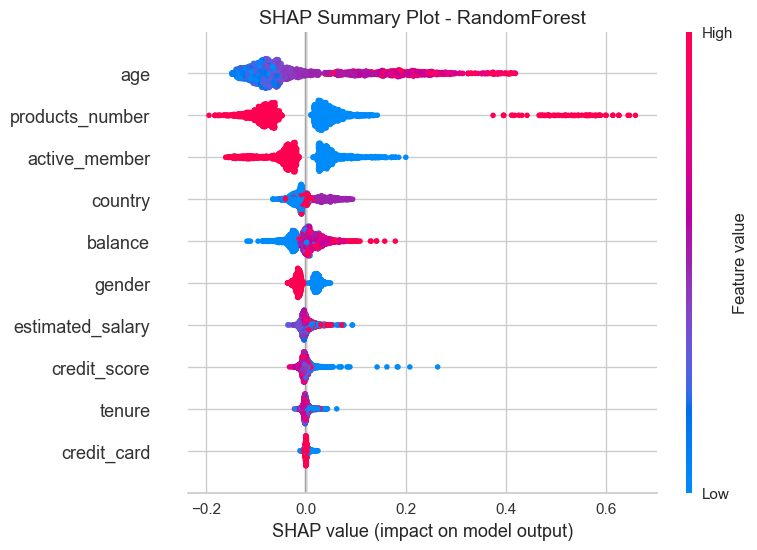

In [36]:
import shap
import matplotlib.pyplot as plt

rf_model = trained_models["RF"] #SHAP value를 계산할 모델 설정 

explainer = shap.TreeExplainer(rf_model) #랜덤포레스트에 맞는 shap explainer 만들기

shap_values = explainer.shap_values(X_valid) #검증 데이터의 shap값을 계산


if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]

elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_values_to_plot = shap_values[:, :, 1] # (샘플 수 , 변수 수, 클래스 수)

else:
    shap_values_to_plot = shap_values

shap.summary_plot(
    shap_values_to_plot,
    X_valid,
    feature_names=X_train_df.columns,  
    plot_type="dot",
    show=False
)

plt.title("SHAP Summary Plot - RandomForest", fontsize=14)
plt.show()

shap 그래프를 보면 age와 products_number가 이탈유무(churn) 예측에 가장 큰 영향을 미치는 변수로 볼 수 있고\
age는 값이 증가할수록 shap value가 양의 방향으로 커지며 약 0.4 증가하는 것을 확인할 수 있다\
이는 나이가 많을수록 churn 확률이 높아지는 경향이 있음을 의미한다

products_number 역시 값이 증가할수록 shap value가 크게 증가하며 최대 약 0.5~0.6정도로 영향을 미친다\
이는 보유한 상품 수가 많을수록 이탈 가능성이 존재하다는 것을 확인할 수 있음

active_member 변수는 뚜렷한 방향성을 보이는데, \
값이 낮을 때 shap value가 약 0.2 수준의 양의 영향을 가지며\
값이 높을 경우 -0.2 수준의 음의 영향을 가지는 것으로 나타났다.\
이는 비활성 고객일수록 churn 가능성이 높고, 활성 고객은 churn 가능성이 낮다는 것을 의미한다

한편 credit_score는 값이 낮을 때만 약 0.2 수준의 양의 영향을 가지며, 전반적으로는 영향력이 크지 않은 것으로 나타났다\
그 외 변수들은 대부분 shap value가 0 근처에 분포하여 churn에 미치는 영향이 상대적으로 적은것으로 확인된다.

In [37]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

est_model_list = [
    ("rf", trained_models["RF"]),
    ("lr", trained_models["LR"]),
    ("svm", trained_models["SVM"]),   #전방모델로 RF, LR, SVM, KNN을 씀 
    ("knn", trained_models["KNN"])
]

stack = StackingClassifier(
    estimators=est_model_list,                         # 전방 모델
    final_estimator=LogisticRegression(max_iter=1000) # 후방 모델
)

stack.fit(X_train, y_train) #stacking 모델 학습

stack_pred = stack.predict(X_valid)

print("Stacking F1-score:", f1_score(y_valid, stack_pred)) #f1-score
print("Stacking Accuracy:", accuracy_score(y_valid, stack_pred)) #accuracy

Stacking F1-score: 0.5805471124620061
Stacking Accuracy: 0.862


1. 나이가 높은 고객군에서 churn 가능성이 증가하는 경향이 있으므로\
고령 고객을 대상으로 한 나이별 맞춤 전략이 필요하다고 판단이 됨

2. active_member 변수에서 확인된 바와 같이\
고객의 활동 여부는 churn을 결정짓는 핵심 요소이므로\
비활성 고객을 활성화시키는 전략이 필요하다.

3. products_number가 많을수록 churn이 증가하는 결과는\
상품 수 증가가 반드시 고객 충성도로 이어지지 않음을 의미하며\
과도한 상품 보유 고객에 대한 전담 관리가 필요하다고 판단이 듦

4. credit_score와 같은 일부 변수는 특정 구간에서만 영향을 가지므로\
전체 평균보다는 구간별 고객 분석을 한 후 조치를 취하는 것이 필요하다고 판단이 됨

5. 또한 앞에 EDA 과정에서도 발견한 성별이나 나라별 churn 데이터의 비율도 존재했기에 \
   단순평균분석이 아닌 집단별 맞춤 전략이 필요하다고 판단이 듦